# Computational Astrophysics: Day 2

## Probability, Bayes' Theorem and Descriptive Statistics

**Kris Sens**

This notebook follows the process from Day 2 in the order that I worked through it. It combines the Python work with the explanations from my notes and a small number of useful additions from the astroML Chapter 3 notebooks.

The main reading was **Chapter 3, pages 70--80, of _Statistics, Data Mining and Machine Learning in Astronomy_**.


## Imports

These are the packages used during the different parts of the work.


In [1]:
from scipy import stats
from matplotlib import pyplot as plt
import numpy as np

## 5. Initial Distribution Practice

I first practised creating a  distribution from SciPy, generating random values and plotting its probability density function.

The uniform distribution between $a$ and $b$ has constant probability density:

\begin{equation}
p(x)=\frac{1}{b-a} \ \  \  \  a\leq x\leq b
\end{equation}


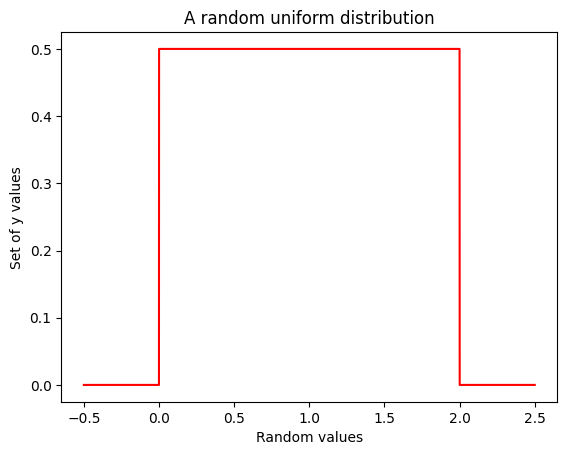

Ten random values:
[0.67933383 1.14430849 0.41055455 1.86657645 1.7783079  0.01604483
 1.48254084 1.51035272 1.85718492 0.75226564]


In [3]:
dist = stats.uniform(loc=0,scale=2)

r = dist.rvs(10)

x = np.linspace(-0.5, 2.5,10000)
y = dist.pdf(x)

plt.plot(x,y, c="red")
plt.title("A random uniform distribution")
plt.xlabel("Random values")
plt.ylabel("Set of y values")

plt.show()

print("Ten random values:")
print(r)

### Gaussian Sampling

The Gaussian probability density is

\begin{equation}
p(x\mid\mu,\sigma)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right]
\end{equation}

I generated a random sample and compared its normalised histogram with the analytic density.


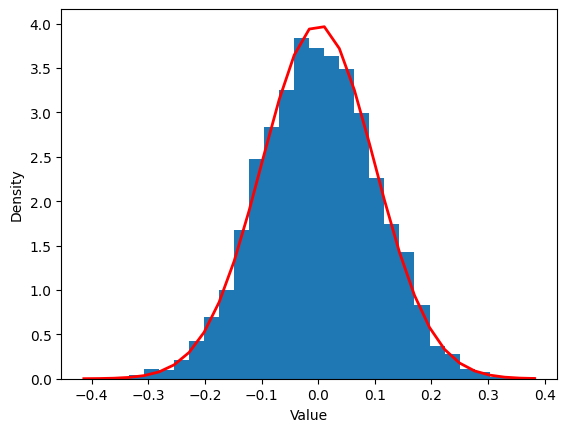

In [5]:
mu, sigma = 0, 0.1
rng = np.random.default_rng()
s = rng.normal(mu, sigma, 5000)


count,bins, ignored = plt.hist(s, 30, density = True)
plt.plot( bins, 1/(sigma * np.sqrt(2*np.pi)) * np.exp( - (bins - mu)**2 / (2* sigma**2)), linewidth=2,color="r" )

plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

## 6. Similar means what do they imply?

I then compared:

1.  one Gaussian centred at zero
2.  a bimodal sample formed by joining two Gaussians centred at +2 and -2

The two datasets can have similar means even though their overall shapes are completely different. This shows why a single summary statistic cannot describe an entire distribution.


In [6]:
sample1 = rng.normal(mu, sigma, 5000)
sample2 = rng.normal(mu+2, sigma, 10000)
sample3 = rng.normal(mu-2, sigma, 10000)


sample_a = sample1
sample_b = np.concatenate([sample2, sample3])

mean_a = np.mean(sample_a)
mean_b = np.mean(sample_b)

median_a = np.median(sample_a)
median_b = np.median(sample_b)

std_a = np.std(sample_a, ddof = 1)
std_b = np.std(sample_b, ddof = 1)

print("Single Gaussian")
print("Mean:", mean_a)
print("Median:", median_a)
print("Standard deviation:", std_a)

print("\nBimodal distribution")
print("Mean:", mean_b)
print("Median:", median_b)
print("Standard deviation:", std_b)

Single Gaussian
Mean: 0.001175686000579115
Median: 0.0011908054823646253
Standard deviation: 0.09874219835992257

Bimodal distribution
Mean: -0.0005865645887593928
Median: 0.004319580516424781
Standard deviation: 2.002386656187011


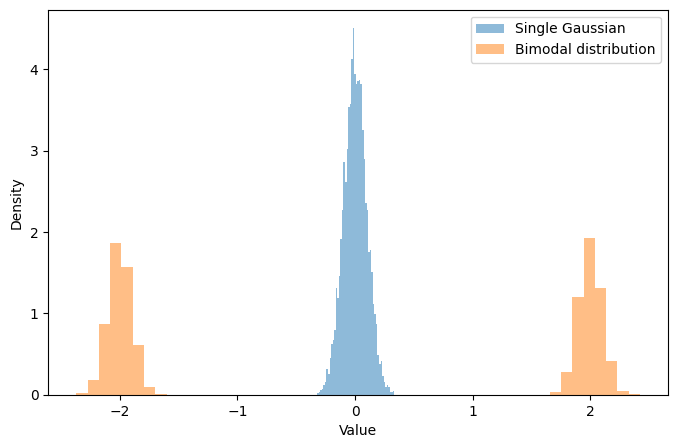

In [7]:
plt.figure(figsize=(8,5))

plt.hist(sample_a, bins = 50, density = True, alpha = 0.5, label = "Single Gaussian")

plt.hist(sample_b, bins = 50, density = True, alpha = 0.5, label = "Bimodal distribution") 

plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## 7. Creating a Summary-Statistics Function

The function below collects several location, scale and shape statistics in one place.

The sample variance and standard deviation use `ddof=1`, while `stats.kurtosis(..., fisher=True)` returns excess kurtosis so that a Gaussian has kurtosis zero.


In [10]:
def summary_stats(values):
    values = np.asarray(values)

    mean = np.mean(values)
    median = np.median(values)
    std = np.std(values,ddof = 1)
    variance = np.var(values, ddof = 1)
    q1,q3 = np.percentile(values, [25,75] ) 
    iqr = q3 - q1
    mad = np.median(np.abs(values - np.median(values)))
    skewness = stats.skew(values, bias = 0)
    kurtosis = stats.kurtosis(values, fisher = True, bias = False)

    return {
        "mean" : mean,
        "median": median,
        "std": std,
        "variance": variance,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "mad": mad,
        "skewness": skewness,
        "kurtosis": kurtosis
    }

print(summary_stats(sample_a))
print(summary_stats(sample_b))

{'mean': np.float64(0.001175686000579115), 'median': np.float64(0.0011908054823646253), 'std': np.float64(0.09874219835992257), 'variance': np.float64(0.009750021736950295), 'q1': np.float64(-0.06367974797310207), 'q3': np.float64(0.06673428559069762), 'iqr': np.float64(0.1304140335637997), 'mad': np.float64(0.06541643303086964), 'skewness': np.float64(0.01859494387876787), 'kurtosis': np.float64(-0.023836920653059757)}
{'mean': np.float64(-0.0005865645887593928), 'median': np.float64(0.004319580516424781), 'std': np.float64(2.002386656187011), 'variance': np.float64(4.009552320875798), 'q1': np.float64(-2.0011253976938352), 'q3': np.float64(1.9981312540332778), 'iqr': np.float64(3.999256651727113), 'mad': np.float64(1.9996138002385355), 'skewness': np.float64(-1.2105937251815014e-05), 'kurtosis': np.float64(-1.9902033677838413)}


### A Robust Gaussian Scale Estimate

A useful robust scale statistic from the astroML descriptive statistics page is

\begin{equation}
\sigma_G=0.7413\left(q_{0.75}-q_{0.25}\right)
\end{equation}

For Gaussian data, this rescales the IQR so that it estimates the Gaussian standard deviation. Unlike the ordinary standard deviation, it is much less sensitive to a small number of extreme values.


In [11]:
q25, q75 = np.percentile(sample_a, [25, 75])
sigma_G = 0.7413 * (q75 - q25)

print("Ordinary sample standard deviation:", np.std(sample_a, ddof=1))
print("Robust Gaussian scale sigma_G:", sigma_G)

Ordinary sample standard deviation: 0.09874219835992257
Robust Gaussian scale sigma_G: 0.0966759230808447


## 8. Contaminating the Data

Real astronomical catalogues can contain outliers, failed measurements or placeholder values. I added an extreme value and several additional observations to the clean Gaussian sample to see how the different statistics respond.

The mean, variance, standard deviation, skewness and kurtosis are expected to react strongly. The median, IQR and median absolute deviation should be more stable.


In [12]:
#What happens when we have very unclean data? Well we will unclean our data ourselves

clean = sample_a.copy()

unclean_sample = np.concatenate([clean, [-9999], [0.5, 0.7, 1.1]])

print("Clean sample")
print(summary_stats(clean))

print("\nUnclean sample")
print(summary_stats(unclean_sample)) #See how the extremes change our data

Clean sample
{'mean': np.float64(0.001175686000579115), 'median': np.float64(0.0011908054823646253), 'std': np.float64(0.09874219835992257), 'variance': np.float64(0.009750021736950295), 'q1': np.float64(-0.06367974797310207), 'q3': np.float64(0.06673428559069762), 'iqr': np.float64(0.1304140335637997), 'mad': np.float64(0.06541643303086964), 'skewness': np.float64(0.01859494387876787), 'kurtosis': np.float64(-0.023836920653059757)}

Unclean sample
{'mean': np.float64(-1.9965670603511396), 'median': np.float64(0.0013039691909488946), 'std': np.float64(141.3507440754843), 'variance': np.float64(19980.03285069306), 'q1': np.float64(-0.06367974797310207), 'q3': np.float64(0.06680015018717841), 'iqr': np.float64(0.1304798981602805), 'mad': np.float64(0.06541881567098651), 'skewness': np.float64(-70.73890291231807), 'kurtosis': np.float64(5003.994922488571)}


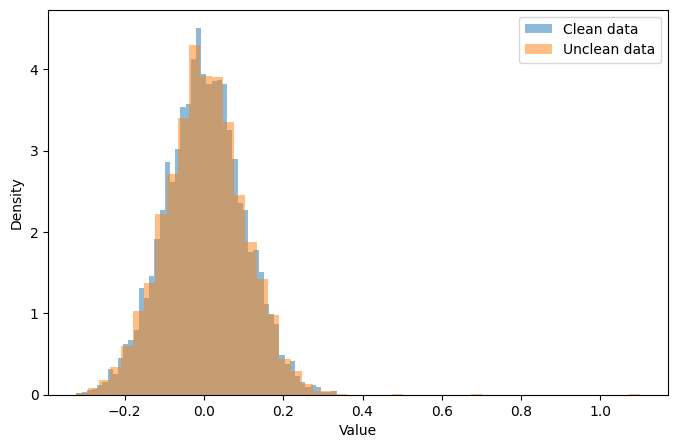

In [13]:
plt_sample = unclean_sample[unclean_sample > -10]

plt.figure(figsize=(8,5))
plt.hist(clean, bins = 50, density = True, alpha = 0.5, label = "Clean data")
plt.hist(plt_sample, bins = 50, density = True, alpha = 0.5, label = "Unclean data")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

## 9. Bessel's Correction

The astroML descriptive statistics notebook demonstrates why `ddof=1` is used for a sample variance.

For many small samples drawn from a Gaussian population, the standard deviation calculated with $N$ in the denominator tends to underestimate the true population spread. Replacing $N$ with $N-1$ reduces this bias.

This experiment generates many samples of size five and compares the two choices.


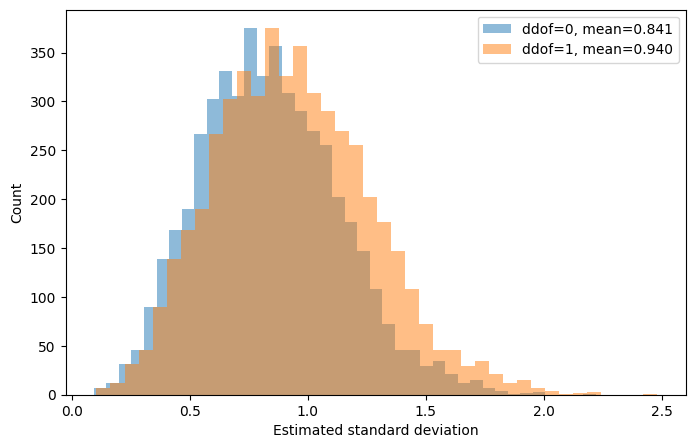

In [14]:
uncorrected = []
corrected = []

for i in range(1,5000):
    samples = rng.normal(loc=5.0, scale=1.0, size=5)
    uncorrected.append(np.std(samples, ddof=0))
    corrected.append(np.std(samples, ddof=1))

plt.figure(figsize=(8,5))
plt.hist(uncorrected, bins=40, alpha=0.5, label=f"ddof=0, mean={np.mean(uncorrected):.3f}")
plt.hist(corrected, bins=40, alpha=0.5, label=f"ddof=1, mean={np.mean(corrected):.3f}")
plt.xlabel("Estimated standard deviation")
plt.ylabel("Count")
plt.legend()
plt.show()

## 10. Applying the Statistics to SDSS Galaxies

I then moved from generated data to the SDSS spectroscopic galaxy catalogue used on Day 1.

The selected columns were:

- `z`: spectroscopic redshift
- `modelMag_g`: model magnitude in the $g$ band
- `modelMag_r`: model magnitude in the $r$ band
- $g-r$: a colour formed by subtracting the two magnitudes

Because astronomical catalogues may contain `NaN` or infinite entries, the real-data function first selects only finite values.


In [15]:
import numpy as np
from matplotlib import pyplot as plt
from astroML.datasets import fetch_sdss_specgals
from scipy import stats
import pandas as pd

data = fetch_sdss_specgals()

# for name in data.dtype.names:
#     print(name)

df = pd.DataFrame(data)
# print(data.head())

df["original_index"] = np.arange(len(df))
#print([col for col in df.columns if "red" in col.lower()]) #Searches through to see if there is any column that has "red" in it

useful = df[
    [
        "original_index",
        "objID",
        "z",
        "modelMag_g",
        "modelMag_r"
    ]
].copy()

useful["g-r"] = useful["modelMag_g"] - useful["modelMag_r"]

print(useful.head())

   original_index                objID         z  modelMag_g  modelMag_r  \
0               0  1237648720142401611  0.021222   15.497092   14.674012   
1               1  1237650795146510627  0.203783   19.131100   17.710718   
2               2  1237650795146445031  0.064656   17.592752   16.673574   
3               3  1237648720142401670  0.052654   18.323746   17.839603   
4               4  1237648720142532891  0.213861   18.648922   17.465515   

        g-r  
0  0.823080  
1  1.420382  
2  0.919178  
3  0.484142  
4  1.183407  


### Summarising Real Catalogue Columns

The function is adapted from the earlier data (that was generated) version, but it now:

- converts the input to floating-point values
- creates a finite-value mask
- reports how many entries were removed
- calculates the statistics only from valid values


In [16]:
def summarise_stats(values):
    values = np.asarray(values, dtype = float)

    finite_m = np.isfinite(values)
    finite_values = values[finite_m]

    if len(finite_values) ==0:
        raise ValueError("No finites HERE MATE!")

    #now the functions we want copy from Day2
    mean = np.mean(finite_values)
    median = np.median(finite_values)
    std = np.std(finite_values,ddof = 1)
    variance = np.var(finite_values, ddof = 1)
    q1,q3 = np.percentile(finite_values, [25,75] ) 
    iqr = q3 - q1
    mad = np.median(np.abs(finite_values - median))
    skewness = stats.skew(finite_values, bias = 0)
    kurtosis = stats.kurtosis(finite_values, fisher = True, bias = False)

    return {
        "total count": len(values),
        "finite values": len(finite_values),
        "unfinite_values": len(values) - len(finite_values),
        "mean" : mean,
        "median": median,
        "std": std,
        "variance": variance,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "mad": mad,
        "skewness": skewness,
        "kurtosis": kurtosis
    }

In [17]:
variables = {
    "redshift": useful["z"],
    "r magnitude": useful["modelMag_r"],
    "g-r colour": useful["g-r"]
}

atable = pd.DataFrame({
    name: summarise_stats(values)
    for name, values in variables.items()
}).T

atable

,total count,finite values,unfinite_values,mean,median,std,variance,q1,q3,iqr,mad,skewness,kurtosis
redshift,661598.0,661598.0,0.0,0.110951,0.103996,0.054505,0.002971,0.071024,0.143380,0.072356,0.035630,0.817849,1.110715
r magnitude,661598.0,661598.0,0.0,17.048621,17.253930,0.723381,0.523280,16.730425,17.571157,0.840732,0.377025,-1.551419,2.978253
g-r colour,661598.0,661598.0,0.0,0.879913,0.890438,0.276186,0.076279,0.700566,1.042652,0.342086,0.168391,1.297519,20.580152


When interpreting the table:

- a large difference between the mean and median can indicate skewness, long tails, invalid values or multiple populations
- a standard deviation much larger than the median absolute deviation can indicate outliers, multimodality or problematic values
- skewness close to zero does not prove that the distribution is Gaussian


## 11. Plotting the SDSS Distributions

The following function plots a normalised histogram and marks the mean and median.

A histogram estimates the underlying density by dividing the data into bins. Its appearance depends on the number and placement of those bins, so it is useful to compare it with numerical summaries rather than interpreting the plot alone.


In [18]:
def plt_distribution(values, label, bins=50):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    mean = np.mean(values)
    median = np.median(values)

    plt.figure(figsize=(8, 5))

    plt.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.7)

    plt.axvline(
        mean,
        linestyle="--",
        label=f"Mean = {mean:.3f}")

    plt.axvline(
        median,
        linestyle=":",
        label=f"Median = {median:.3f}")

    plt.xlabel(label)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
plt_distribution(useful["g-r"], "g-r")
plt_distribution(useful["z"], "redshift")
plt_distribution(useful["modelMag_r"], "magnitude of r band")

## 12. The Empirical Cumulative Distribution Function

The empirical cumulative distribution function, or ECDF, gives the fraction of observations less than or equal to a chosen value $x$:

\begin{equation}
F_N(x)=\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}(x_i\leq x)
\end{equation}

Unlike a histogram, the ECDF does not require a choice of bin width. It retains every observation and makes quantiles easy to read from the cumulative fraction.


In [ ]:
def ecdf(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x)

    return x, y

x, y = ecdf(useful["g-r"])

plt.figure(figsize=(8, 5))
plt.plot(x, y)
plt.xlabel("g-r colour")
plt.ylabel("Cumulative fraction")
plt.tight_layout()
plt.show()

## 13. Creating a Clean Working Catalogue

The final finite mask requires valid redshift, $g$-band magnitude, $r$-band magnitude and $g-r$ colour values simultaneously.

Keeping `original_index` means that rows in the cleaned DataFrame can still be traced back to their positions in the original catalogue.


In [19]:
finite_mask = (
    np.isfinite(useful["z"]) &
    np.isfinite(useful["modelMag_g"]) &
    np.isfinite(useful["modelMag_r"]) &
    np.isfinite(useful["g-r"])
)

clean_useful = useful.loc[finite_mask].copy()

print("Original rows:", len(useful))
print("Rows after requiring finite values:", len(clean_useful))
clean_useful.head()

Original rows: 661598
Rows after requiring finite values: 661598


,original_index,objID,z,modelMag_g,modelMag_r,g-r
0,0,1237648720142401611,0.021222,15.497092,14.674012,0.823080
1,1,1237650795146510627,0.203783,19.131100,17.710718,1.420382
2,2,1237650795146445031,0.064656,17.592752,16.673574,0.919178
3,3,1237648720142401670,0.052654,18.323746,17.839603,0.484142
4,4,1237648720142532891,0.213861,18.648922,17.465515,1.183407


## Resources Used

### My own notes

- [Computational Astrophysics Day 2 LaTeX notes](https://www.overleaf.com/read/shvszwqgcbqb#ec2ffe)

### Main reading

- _Statistics, Data Mining and Machine Learning in Astronomy_, Chapter 3, pages 70--80

### astroML Chapter 3

- [Overview of Probability and Random Variables](https://www.astroml.org/astroML-notebooks/chapter3/astroml_chapter3_Overview_of_Probability_and_Random_Variables.html)
- [Descriptive Statistics](https://www.astroml.org/astroML-notebooks/chapter3/astroml_chapter3_Descriptive_Statistics.html)

### Bayesian introduction

- [Introduction to Bayesian Statistics](https://www.youtube.com/watch?v=NIqeFYUhSzU)

### Dataset

- [astroML: `fetch_sdss_specgals`](https://www.astroml.org/modules/generated/astroML.datasets.fetch_sdss_specgals.html)

### Python learning and documentation

- [Zero to Mastery NumPy introduction](https://dev.mrdbourke.com/zero-to-mastery-ml/introduction-to-numpy/)
- [SciPy statistical functions](https://docs.scipy.org/doc/scipy/reference/stats.html)
- [Matplotlib histogram normalisation](https://matplotlib.org/stable/gallery/statistics/histogram_normalization.html)
- [NumPy random normal samples](https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html)
- [IQR using NumPy and SciPy](https://www.geeksforgeeks.org/numpy/interquartile-range-and-quartile-deviation-using-numpy-and-scipy/)
- [Skewness and kurtosis in Python](https://www.geeksforgeeks.org/data-science/how-to-calculate-skewness-and-kurtosis-in-python/)
